## Bivariate Moon example

The goal of this notebook is to verify that normalizing flows is appropriate for transforming different distributions into a normal distribution while maintaining outlier structure.

In [0]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import normflows as nf
from tqdm.notebook import tqdm

from scipy import stats
from scipy.spatial import distance

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons

from pingouin import multivariate_normality

import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


In [0]:
sns.set_theme(style='white')

We define the main function to estimate the bijection to map from the complex \\(X\\)-space to the base distribution (Gaussian) \\(Z\\)-space. Note that the loss function is the sum of the \\(KL\\)-divergence and penalized by penalized by the logarithm of the non-unit Jacobian of the bijection squared with parameter \\(\lambda\\) in order to reduce wiggliness of the bijection. We attempt to match the target distribution (i.e. the Moons \\(p_\mathbf{X}(\mathbf{x}; \bm{\theta})\\)) with a flow-based model \\(p^*_\mathbf{X}(\mathbf{x}; \bm{\theta})\\) while penalizing for large movements required to approximate normality.

\\[\mathcal{L} = D_{KL}\left[ p^*_\mathbf{X}(\mathbf{x}) \|| p_\mathbf{X}(\mathbf{x}; \bm{\theta})\right] + \lambda \log^2 (|\det J(f|z)|), \\]

where \\(J\\) is the matrix of first derivatives (Jacobian) of \\(f\\).


In [0]:
def norm_flow(input_data, K, hidden_layers, hidden_units, iter, lam):

    # Number of bijections
    K = K

    # Latent size
    latent_size = input_data.shape[1]

    # NN architecture
    hidden_units = hidden_units
    hidden_layers = hidden_layers

    # Scale input data
    scaler = StandardScaler()
    input_data = scaler.fit_transform(input_data)

    # Set up the flows
    flows = []
    for i in range(K):
        flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units, permute_mask=True, init_identity=True)]
        flows += [nf.flows.ActNorm(latent_size)]

    # Set base distribution
    q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)
        
    # Construct flow model
    mod = nf.NormalizingFlow(q0, flows)

    enable_cuda = True
    device = torch.device('cuda')
    
    # Move model on GPU if available
    mod = mod.to(device)

    # Train model
    max_iter = iter
    optimizer = torch.optim.AdamW(mod.parameters(), lr=3e-4)

    x = torch.tensor(input_data, dtype=torch.float32, device=device)
    
    for it in tqdm(range(max_iter), desc='Normflow', position=1):
        optimizer.zero_grad()

        # Define the loss function
        _, jac = mod.inverse_and_log_det(x)
        loss = mod.forward_kld(x) + lam*torch.mean(jac**2)
        
        # Do backprop and optimizer step
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            optimizer.step()

    # EZ = np.mean((x - mod.inverse(x)).to('cpu').detach().numpy()**2)
    # print("MSE from X to Z: ", EZ)

    return mod, mod.inverse(torch.tensor(input_data, dtype=torch.float32, device=device)).to('cpu').detach().numpy()

First we sample from the distribution.

In [0]:
n = 10000
np.random.seed(123)

In [0]:
sigma = 0.1
moon, y = make_moons(n, noise=sigma)

Plotting the SHAP values.

<Axes: xlabel='x', ylabel='y'>

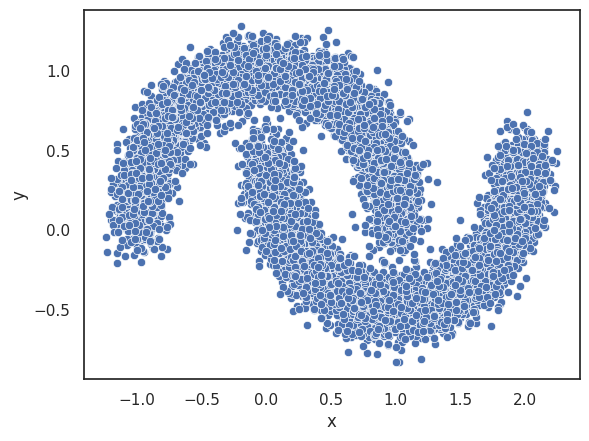

In [0]:
sns.scatterplot(data=pd.DataFrame(moon, columns=['x', 'y']), x='x', y='y')

We apply the normalizing flows by first tuning \\(\lambda\\).

In [0]:
for j, i in enumerate(np.concatenate([np.array([0]), np.exp(np.linspace(-5,1,30))])):
    print("lambda: ", i)
    mod, z_moon = norm_flow(moon, 10, 2, 10, 500, i)

    print(multivariate_normality(z_moon))

    pval = multivariate_normality(z_moon).pval

    if pval < 0.01:
        break
lam = np.concatenate([np.array([0]), np.exp(np.linspace(-5,1,30))])[j-1]
print("Final lambda: ", lam)

lambda:  0.0


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

HZResults(hz=0.5216690770020599, pval=0.9953508155256744, normal=True)
lambda:  0.006737946999085467


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

HZResults(hz=0.49236994487514285, pval=0.9981247259809786, normal=True)
lambda:  0.008286700089278946


...

HZResults(hz=0.5209299750453394, pval=0.995448780940439, normal=True)
lambda:  0.015415006544294353


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

HZResults(hz=0.7352477471111313, pval=0.7979908483887388, normal=True)
lambda:  0.018958228095913708


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

HZResults(hz=2.7848021987118834, pval=8.703937093379867e-10, normal=False)
Final lambda:  0.015415006544294353


In [0]:
lam

0.015415006544294353

In [0]:
N = 1000

y_final = {}
counter = 0
for i in tqdm(range(N), desc='Simulation', position=0):
    mod, z = norm_flow(moon, 10, 2, 10, 500, lam)

    print(multivariate_normality(z))

    if multivariate_normality(z).pval > 0.01:
        counter += 1
        x, y = np.mgrid[-2:2:.1, -1.5:1.5:.1]
        pos = np.column_stack((x.flat, y.flat))

        with torch.no_grad():
            y_transformed = pd.DataFrame(mod.forward(torch.tensor(pos, dtype=torch.float32, device='cuda')).to('cpu').detach().numpy())

        y_final[i] = y_transformed
        
y_final = [val for val in y_final.values() if val is not None] 
y_moon = pd.concat(y_final, axis=0, ignore_index=True)
y_moon['it'] = np.repeat(list(range(len(y_final))), repeats=y_final[0].shape[0])

And now for the resampling method.

In [0]:
N = 1000
y_final_boot = {}
counter_boot = 0
for i in tqdm(range(N), desc='Simulation', position=0):

    indices = np.random.choice(moon.shape[0], moon.shape[0], replace=True)
    moon_2 = moon[indices]
    mod, z = norm_flow(moon_2, 10, 2, 10, 500, lam)

    # Assess normality
    print(multivariate_normality(z))

    if multivariate_normality(z).pval > 0.01:
        counter_boot += 1
        x, y = np.mgrid[-2:2:.1, -1.5:1.5:.1]
        pos = np.column_stack((x.flat, y.flat))
        with torch.no_grad():
            y_transformed = pd.DataFrame(mod.forward(torch.tensor(pos, dtype=torch.float32, device='cuda')).to('cpu').detach().numpy())

        y_final_boot[i] =  y_transformed
        
y_final_boot = [val for val in y_final_boot.values() if val is not None] 
y_moon_boot = pd.concat(y_final_boot, axis=0, ignore_index=True)
y_moon_boot['it'] = np.repeat(list(range(len(y_final_boot))), repeats=y_final_boot[0].shape[0])

Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

HZResults(hz=0.9228892181557813, pval=0.3686153754302593, normal=True)


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

HZResults(hz=1.024984801155232, pval=0.19062459469502957, normal=True)


...

Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

HZResults(hz=0.63948563469092, pval=0.9397570310363738, normal=True)


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

HZResults(hz=1.2346627161523989, pval=0.033355814983184545, normal=False)


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

In [0]:
print("Number of passes:", counter, counter_boot)

We calculate and plot the transformation with varying seed. We use a quiver plot because the transformation is from \\(\mathbb{R}^2\\) to \\(\mathbb{R}^2\\). We examine the variability in magnitude and in the angle of transformation.

In [0]:
# Caluclate variability in magnitude and angle
dis = []
ang = []
x, y = np.mgrid[-2:2:.1, -1.5:1.5:.1]
pos = np.column_stack((x.flat, y.flat))
pos_new = np.vstack([pos]*len(y_final))
for i in range(y_moon.shape[0]):
    dis.append(distance.euclidean(y_moon.iloc[i,:2].to_numpy(), pos_new[i]))
    ang.append(np.arctan((y_moon.iloc[i,1] - pos_new[i,1])/(y_moon.iloc[i,0] - pos_new[i,0]))*180/np.pi)

y_moon['dist'] = pd.Series(dis)
y_moon['angle'] = pd.Series(ang)

y_moon['x'] = list(range(pos.shape[0]))*len(y_final)

dis_var = y_moon[['it', 'dist', 'x']].groupby('x')['dist'].std()
ang_var = y_moon[['it', 'angle', 'x']].groupby('x')['angle'].std()

In [0]:
y_moon_avg = y_moon[[0, 1, 'x']].groupby('x').mean()

In [0]:
# Plot variability in magnitude
plt.quiver(pos[:,0], pos[:,1], y_moon_avg.iloc[:,0], y_moon_avg.iloc[:,1], dis_var, scale=90)
plt.colorbar()
plt.scatter(moon[:,0] - moon.mean(axis=0)[0], moon[:,1] -moon.mean(axis=0)[1], alpha=.02, label='shap')



In [0]:
# Plot variability in angle
plt.quiver(pos[:,0], pos[:,1], y_moon_avg.iloc[:,0], y_moon_avg.iloc[:,1], ang_var, scale=100)
plt.colorbar()
plt.scatter(moon[:,0]-moon.mean(axis=0)[0], moon[:,1]-moon.mean(axis=0)[1], alpha=.02, label='shap')

We calculate and plot the transformation with bootstrap. We use a quiver plot because the transformation is from \\(\mathbb{R}^2\\) to \\(\mathbb{R}^2\\). We examine the variability in magnitude and in the angle of transformation.

In [0]:
# Calculate the variability in magitude and angle
dis = []
ang = []
x, y = np.mgrid[-2:2:.1, -1.5:1.5:.1]
pos = np.column_stack((x.flat, y.flat))
pos_new = np.vstack([pos]*len(y_final_boot))
for i in range(y_moon_boot.shape[0]):
    dis.append(distance.euclidean(y_moon_boot.iloc[i,:2].to_numpy(), pos_new[i]))
    ang.append(np.arctan((y_moon_boot.iloc[i,1] - pos_new[i,1])/(y_moon_boot.iloc[i,0] - pos_new[i,0]))*180/np.pi)

y_moon_boot['dist'] = pd.Series(dis)
y_moon_boot['angle'] = pd.Series(ang)

y_moon_boot['x'] = list(range(pos.shape[0]))*len(y_final_boot)

dis_var_boot = y_moon_boot[['it', 'dist', 'x']].groupby('x')['dist'].std()
ang_var_boot = y_moon_boot[['it', 'angle', 'x']].groupby('x')['angle'].std()

In [0]:
y_moon_boot_avg = y_moon_boot[[0, 1, 'x']].groupby('x').mean()

In [0]:
# Plot variability in magnitude
plt.quiver(pos[:,0], pos[:,1], y_moon_boot_avg.iloc[:,0], y_moon_boot_avg.iloc[:,1], dis_var_boot, scale=100)
plt.colorbar()
plt.scatter(moon[:,0]-moon.mean(axis=0)[0], moon[:,1]-moon.mean(axis=0)[1], alpha=.02, label='shap')

In [0]:
# Plot variability in angle
plt.quiver(pos[:,0], pos[:,1], y_moon_boot_avg.iloc[:,0], y_moon_boot_avg.iloc[:,1], ang_var_boot, scale=100)
plt.colorbar()
plt.scatter(moon[:,0]-moon.mean(axis=0)[0], moon[:,1]-moon.mean(axis=0)[1], alpha=.02, label='shap')


Finally we plot the transformed distribution.

In [0]:
mod, z_moon = norm_flow(moon, 10, 2, 10, 500, lam)
sns.scatterplot(pd.DataFrame(z_moon, columns=['x', 'y']), x='x', y='y')